![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/notebooks_banner_withframe.png)

# Reclassifying a GeoTIFF raster

Author details: Dr Ryan Newis

Editor details: Xiang Zhao

Contact details: support\@ecocommons.org.au

Copyright statement: This script is the product of the EcoCommons platform. Please refer to the EcoCommons website for more details: <https://www.ecocommons.org.au/>

Date: March 2026

# Script and Data Information

This notebook provides a simple, reproducible example of reclassifying a continuous GeoTIFF raster (.tif) into categorical habitat suitability classes using the `terra` package in R. It is designed as a lightweight template that can be adapted to prediction rasters generated from species distribution models (SDM) or other spatial modelling workflows.

The notebook demonstrates how to convert continuous suitability values into both binary and multi-class suitability maps, visualise the resulting classifications, and export the outputs in GeoTIFF file format for downstream spatial analysis or use in GIS spatial software (e.g. QGIS).

The example GeoTIFF raster used in this notebook is output derived from an SDM using Maxent algorithm. The continuous habitat suitability prediction is for the the Sooty Oystercatcher (*Haematopus fuliginosus*) and the modelling workflow was conducted on the EcoCommons platform. Original occurrence data was obtained from the Atlas of Living Australia (<https://www.ala.org.au>) via the EcoCommons platform.

# Introduction

Many spatial modelling workflows commonly produce continuous prediction rasters, where each grid cell contains a value representing the relative suitability or probability of species occurrence. These continuous surfaces are highly informative but can sometimes be difficult to interpret directly, particularly when communicating model outputs to non-technical audiences or integrating predictions into decision-making frameworks. Reclassification provides a simple and widely used approach for summarising continuous predictions into a smaller number of discrete categories. For example, suitability values can be divided into binary classes that distinguish unsuitable from potentially suitable habitat, or into multiple classes representing low, moderate, and high suitability.

Although reclassification is conceptually straightforward, it is important to apply thresholds transparently and ensure that the resulting classifications preserve the spatial integrity of the original prediction raster. Careful visualisation and documentation of these steps help maintain reproducibility and clarity in modelling workflows. This notebook demonstrates a structured approach to reclassifying a continuous prediction raster as well as visualising and exporting the resulting suitability maps.

# Key Concepts

## K.1 Continuous prediction rasters

Continuous prediction rasters represent spatial predictions as a grid of values, typically ranging from 0 to 1. Each grid cell contains a predicted suitability value derived from a modelling algorithm such as MaxEnt, Random Forest, or Boosted Regression Trees. These rasters represent continuous gradients of predicted suitability rather than discrete habitat categories.

## K.2 Raster reclassification

Raster reclassification is the process of grouping continuous raster values into discrete categories using defined threshold values. This transformation can simplify interpretation and support comparison of predicted suitability across space. Reclassification is commonly used to generate maps representing categories such as unsuitable habitat, moderate suitability, or highly suitable habitat.

## K.3 Threshold values

Thresholds define the boundaries between suitability classes during raster reclassification. These thresholds may be derived from model evaluation metrics, statistical summaries of prediction values, or ecological expertise. In species distribution modelling, thresholds are often used to convert continuous predictions into binary maps indicating predicted presence or absence.

# Notebook objectives

1.  Demonstrate how to read a GeoTIFF (.tif) prediction raster into R as a SpatRaster object using the `terra` package.
2.  Perform a basic visual inspection of the continuous prediction raster to confirm that the dataset has been loaded correctly.
3.  Reclassify the continuous prediction raster into a binary habitat suitability map based on a defined threshold.
4.  Reclassify the raster into a three-class suitability map representing low, moderate, and high predicted suitability.
5.  Visualise the reclassified rasters to confirm that the classifications were applied correctly.
6.  Export the reclassified rasters as GeoTIFF files for use in GIS software or downstream spatial analyses.

# Workflow Overview

This notebook follows a simple, linear workflow to reclassify and visualise a prediction raster:

-   Step 1: Set up the R environment and load the required packages (`terra`, `googledrive`, `ggplot2`, `viridis`).

-   Step 2: Load a continuous prediction raster (.tif) into R and perform a visual check to confirm that the raster was read correctly.

-   Step 3: Visualise input raster

-   Step 4: Reclassify the continuous prediction and visualise outputs:

    -   a binary suitability raster, and
    -   a three-class suitability raster using defined threshold values.

-   Step 5: Export the reclassified rasters as GeoTIFF (.tif) files for use in GIS software or other spatial workflows.

Important: Reclassification simplifies continuous predictions and may obscure fine-scale variation in suitability values. Threshold selection should therefore be carefully considered and documented, particularly when predictions are used to support ecological interpretation or management decisions.

In the near future, this material may form part of comprehensive support materials available to EcoCommons users. If you have any corrections or suggested improvements, please [contact the EcoCommons](mailto:support@ecocommons.org.au) team.

![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/EC_breaker_nobackgoundcolor.png)

## Step 1. Install and load required packages

Install and load R packages and libraries that are not present in the work environment. This process might take some time as some packages needed to be installed for the first time.


In [1]:

# Required packages
required_packages <- c(
  "terra",         # spatial functions
  "googledrive",   # downloading example raster
  "ggplot2",       # plotting
  "viridis"        # colour palette for plotting
)

# Identify missing packages
missing_packages <- required_packages[!(required_packages %in% installed.packages()[,"Package"])]

# Install missing packages
if (length(missing_packages) > 0) {
  cat("Installing missing packages...\n\n")
  install.packages(missing_packages, quiet = TRUE)
}

# Load packages with clean messages
for (pkg in required_packages) {
  suppressPackageStartupMessages(
    library(pkg, character.only = TRUE)
  )
  cat("✔", pkg, "loaded successfully\n")
}

cat("\nAll required packages are ready.\n")


✔ terra loaded successfully
✔ googledrive loaded successfully


Warning message:
“package ‘ggplot2’ was built under R version 4.5.2”


✔ ggplot2 loaded successfully


Warning message:
“package ‘viridisLite’ was built under R version 4.5.2”


✔ viridis loaded successfully

All required packages are ready.



## Step 2. Load Prediction Raster

This notebook requires a continuous prediction raster in GeoTIFF format, containing habitat suitability values (typically between 0 and 1).

You may either:

-   Use the example continuous prediction raster provided (Sooty oystercatcher) with this notebook (sourced from GoogleDrive), or
-   Upload your own prediction raster generated from a SDM workflow.

If you want upload your own prediction raster, update the file path (Option 1) in the code chunk below.


In [2]:

# OPTION 1: User-defined local GeoTIFF file
tif_file <- NULL
#tif_file <- "/path_to_your_file"


# OPTION 2: Download example GeoTIFF if no local file
if (is.null(tif_file)) {

  drive_deauth()

  workspace <- getwd()
  datafolder_path <- file.path(workspace, "data")

  if (!dir.exists(datafolder_path)) {
    dir.create(datafolder_path, recursive = TRUE)
  }

  tif_file_id <- "1cXlLLrunLTtuWZHHUg5TeAFbD2iil0qJ"

  # Get file metadata (to retrieve original name)
  file_info <- drive_get(as_id(tif_file_id))

  # Build full local path using original filename
  tif_file <- file.path(datafolder_path, file_info$name)

  # Download to that exact file path
  drive_download(
    as_id(tif_file_id),
    path = tif_file,
    overwrite = TRUE
  )
}

# Final safety check
if (!file.exists(tif_file)) {
  stop("Input GeoTIFF file not found.")
}


# Extract base file name (used downstream)
base_name <- tools::file_path_sans_ext(basename(tif_file))


File downloaded:

• Haematopus_fuliginosus_maxent_cont_pred_cloglog.tif
  <id: 1cXlLLrunLTtuWZHHUg5TeAFbD2iil0qJ>

Saved locally as:

• /Users/xiangzhaoqcif/dev/notebooks_zhaoxiangmax/notebooks/data/Haematopus_fuliginosus_maxent_cont_pred_cloglog.tif




## Step 3. Visualise input raster (Continuous Prediction)

Before reclassifying the raster, it is useful to visualise the **continuous habitat suitability prediction**.

Continuous prediction rasters typically contain values between **0 and 1**, where:

-   Lower values indicate lower predicted suitability
-   Higher values indicate higher predicted suitability

Inspecting the plotted raster helps confirm that the prediction was loaded correctly and provides context for the reclassification steps that follow. We also inspect valuable metadata such as: CRS, extent and resolution.


Warning message:
“Raster pixels are placed at uneven horizontal intervals and will be shifted
ℹ Consider using `geom_tile()` instead.”


class       : SpatRaster 
size        : 681, 822, 1  (nrow, ncol, nlyr)
resolution  : 0.05, 0.05  (x, y)
extent      : 112.925, 154.025, -44.025, -9.975  (xmin, xmax, ymin, ymax)
coord. ref. : lon/lat WGS 84 (EPSG:4326) 
source      : Haematopus_fuliginosus_maxent_cont_pred_cloglog.tif 
name        :       maxent 
min value   : 0.0004144257 
max value   : 0.9002557397 


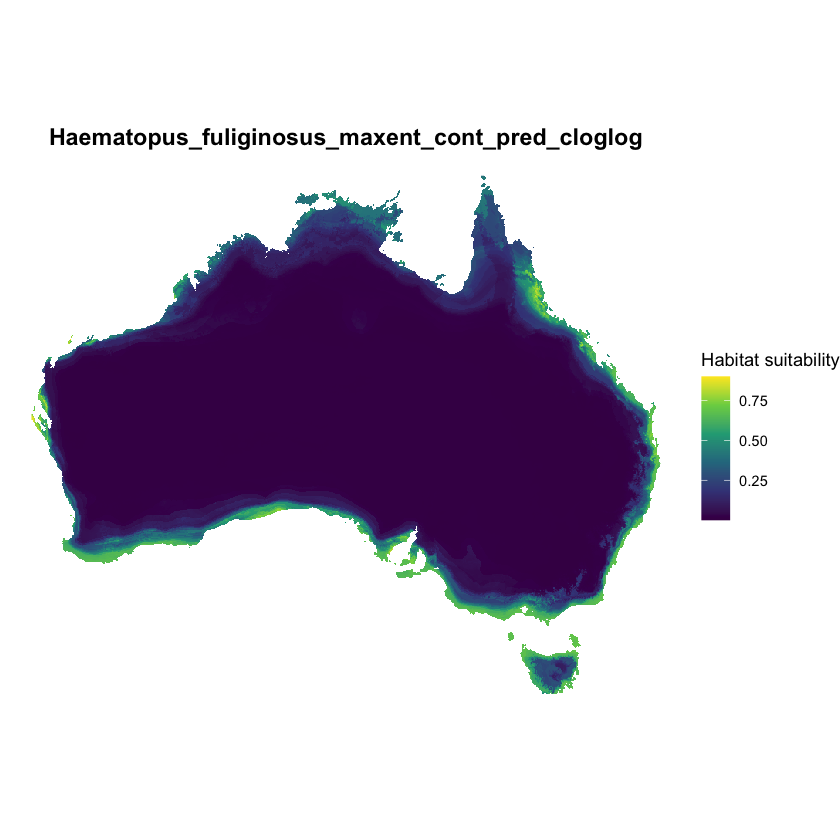

In [3]:

# Read prediction raster into R
predicted_model <- terra::rast(tif_file)


# Convert SpatRaster to data frame for plotting
prediction_df <- terra::as.data.frame(
  predicted_model,
  xy = TRUE,
  na.rm = TRUE
)

# Rename prediction column
names(prediction_df)[3] <- "suitability"

# Plot continuous habitat suitability
ggplot(prediction_df) +
  geom_raster(aes(x = x, y = y, fill = suitability)) +
  scale_fill_viridis_c(
    option = "viridis",
    name = "Habitat suitability"
  ) +
  coord_equal() +
  theme_void() +
  theme(
    plot.title = element_text(
      size = 14,
      face = "bold",
      hjust = 0.5
    )
  ) +
  labs(
    title = base_name
  )

print(predicted_model)



## Step 4. Reclassifying Prediction Raster

Continuous habitat suitability predictions can be converted into simpler categories using threshold values.

This section demonstrates two common approaches:

-   **Binary classification**
    -   unsuitable habitat
    -   potentially suitable habitat
-   **Three-class classification**
    -   unlikely to occur
    -   may occur
    -   likely to occur

These classifications help simplify interpretation and are commonly used for mapping and reporting species distribution model outputs.

### 4.1 Binary habitat suitability reclassification

Binary classification separates habitat into two categories using a single threshold value.

Grid cells with suitability values:

-   **below the threshold** are classified as unsuitable habitat (0)
-   **equal to or above the threshold** are classified as potential suitable habitat (1)

In the code below we define a threshold and apply it to the continuous prediction raster to create a binary suitability map. The threshold used is case specific and is generally derived from the output metrics from SDM modelling workflows (e.g. Maxent/GLM). In this example we choose an arbitrary number of 0.35, however this can be changed as per user requirements.


In [4]:

# Define binary suitability threshold - adjust binary threshold metric as required
threshold_binary <- 0.35

cat("Binary threshold used:", threshold_binary, "\n")

# Create binary raster
binary_raster <- terra::ifel(predicted_model >= threshold_binary, 1, 0)

cat("Binary raster created successfully\n")


Binary threshold used: 0.35 
Binary raster created successfully



### 4.2 Plot binary habitat suitability reclassification

The binary raster can now be visualised to show the two suitability categories derived from the continuous prediction raster.

The map displays:

-   **Unsuitable habitat** (values below the defined threshold)
-   **Potential suitable habitat** (values equal to or above the threshold)

This simplified classification highlights areas predicted to contain suitable habitat and is commonly used for reporting or comparing model predictions. Names of reclassified categories can be adjusted as required.


Warning message:
“Raster pixels are placed at uneven horizontal intervals and will be shifted
ℹ Consider using `geom_tile()` instead.”


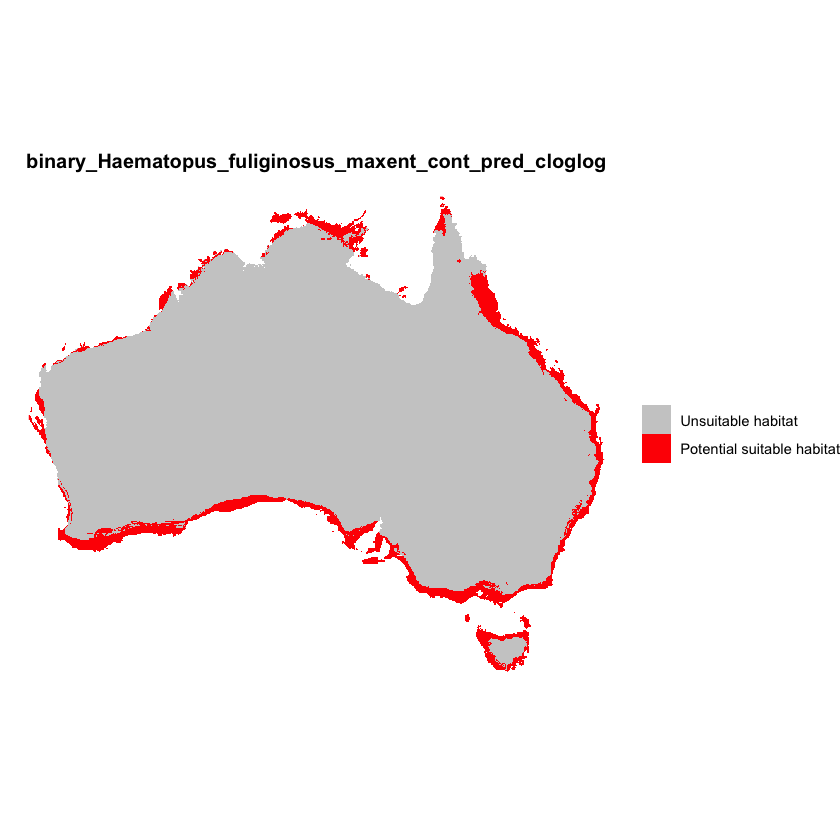

In [5]:

# Convert raster to dataframe for plotting
binary_df <- terra::as.data.frame(binary_raster, xy = TRUE, na.rm = TRUE)

# Rename suitability column
names(binary_df)[3] <- "suitability"

# Convert to labelled factor (name binary classes)
binary_df$suitability_label <- factor(
  binary_df$suitability,
  levels = c(0, 1),
  labels = c("Unsuitable habitat", "Potential suitable habitat")
)

# Plot binary suitability map
ggplot(binary_df) +
  geom_raster(aes(x = x, y = y, fill = suitability_label)) +
  scale_fill_manual(
    values = c(
      "Unsuitable habitat" = "grey80",
      "Potential suitable habitat" = "red"
    ),
    name = NULL
  ) +
  coord_equal() +
  theme_void() +
  theme(
    plot.title = element_text(
      size = 12,
      face = "bold",
      hjust = 0.5
    ),
    legend.position = "right"
  ) +
  labs(
    title = paste0("binary_", base_name)
  )



### 4.3 Three-class habitat suitability reclassification

Continuous habitat suitability predictions can also be divided into multiple classes to provide a more nuanced interpretation of predicted species occurrence.

In this example we define two thresholds to create a 3 class prediction raster:

-   **T1** separates low and moderate suitability
-   **T2** separates moderate and high suitability

Grid cells are classified as:

| Class | Interpretation    |
|-------|-------------------|
| 1     | Unlikely to occur |
| 2     | May occur         |
| 3     | Likely to occur   |

These thresholds are applied to the continuous prediction raster to produce a **three-class habitat suitability map**. The thresholds used are case specific and are generally derived from the output metrics from SDM modelling workflows (e.g. Maxent/GLM). In this example we choose an arbitrary threshold metrics of T1 = 0.20 and T2 = 0.55, however these metrics can be changed as per user requirements. The user can also adjust the code below to add and/or rename classes.


In [6]:

# Define thresholds - adjust class threshold metrics as needed
T1 <- 0.20
T2 <- 0.55

cat("3-class thresholds used:\n")
cat("T1 =", T1, "\n")
cat("T2 =", T2, "\n")

# Reclassify raster
threeclass_raster <- terra::ifel(
  predicted_model < T1, 1,
  terra::ifel(predicted_model < T2, 2, 3)
)

cat("3-class raster created successfully\n")



3-class thresholds used:
T1 = 0.2 
T2 = 0.55 
3-class raster created successfully



### 4.4 Plot three-class habitat suitability reclassification

The reclassified raster can now be visualised to show the three suitability categories derived from the continuous prediction raster.

The map displays:

-   **Unlikely to occur** (low suitability)
-   **May occur** (moderate suitability)
-   **Likely to occur** (high suitability)

These classes provide a simplified interpretation of the continuous habitat suitability predictions. Names of reclassified categories can be adjusted as required.


Warning message:
“Raster pixels are placed at uneven horizontal intervals and will be shifted
ℹ Consider using `geom_tile()` instead.”


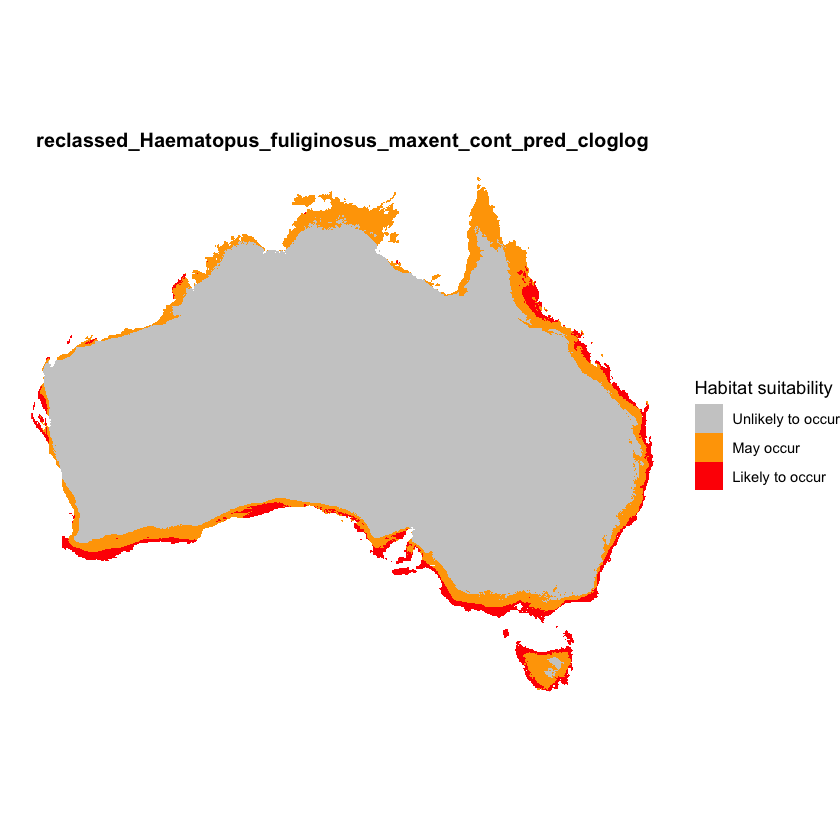

In [7]:

# Convert raster to dataframe for plotting
class_df <- terra::as.data.frame(threeclass_raster, xy = TRUE, na.rm = TRUE)

# Rename column
names(class_df)[3] <- "suitability_class"

# Convert to labelled factor (name each class)
class_df$suitability_label <- factor(
  class_df$suitability_class,
  levels = c(1, 2, 3),
  labels = c(
    "Unlikely to occur",
    "May occur",
    "Likely to occur"
  )
)

# Plot three-class suitability map
ggplot(class_df) +
  geom_raster(aes(x = x, y = y, fill = suitability_label)) +
  scale_fill_manual(
    values = c(
      "Unlikely to occur" = "grey80",
      "May occur" = "orange",
      "Likely to occur" = "red"
    ),
    name = "Habitat suitability"
  ) +
  coord_equal() +
  theme_void() +
  theme(
    plot.title = element_text(
      size = 12,
      face = "bold",
      hjust = 0.5
    ),
    legend.position = "right"
  ) +
  labs(
    title = paste0("reclassed_", base_name)
  )



## Step 5. Export reclassified rasters

The reclassified prediction rasters can now be exported for use in GIS software or other spatial analyses.

Users can specify an **output directory** where the files will be saved.\
If the directory does not exist, it will be created automatically in the same folder as the input raster.

The following files will be saved to the the output folder:

-   **Binary habitat suitability raster**
-   **Three-class habitat suitability raster**


In [8]:

# ---------------------------------------------------
# Define output directory (same as input raster)
# ---------------------------------------------------

# Option 1: Default output folder - data folder that input file came from. Comment out this line if specifying different output folder in Option 2
out_dir <- dirname(tif_file)

# Option 2: Save outputs to a different folder (uncomment and edit)
# out_dir <- "/your outputs folder"

# ---------------------------------------------------
# Save binary raster (if it exists)
# ---------------------------------------------------

if (exists("binary_raster")) {

  binary_path <- file.path(
    out_dir,
    paste0(base_name, "_binary_reclassification.tif")
  )

  terra::writeRaster(
    binary_raster,
    binary_path,
    overwrite = TRUE
  )

  cat("Binary raster written to:\n", binary_path, "\n\n")

} else {

  cat("Binary raster not found — skipping export.\n\n")

}

# ---------------------------------------------------
# Save 3-class raster (if it exists)
# ---------------------------------------------------

if (exists("threeclass_raster")) {

  three_class_path <- file.path(
    out_dir,
    paste0(base_name, "_3class_reclassification.tif")
  )

  terra::writeRaster(
    threeclass_raster,
    three_class_path,
    overwrite = TRUE
  )

  cat("Three-class raster written to:\n", three_class_path, "\n")

} else {

  cat("Three-class raster not found — skipping export.\n")

}


Binary raster written to:
 /Users/xiangzhaoqcif/dev/notebooks_zhaoxiangmax/notebooks/data/Haematopus_fuliginosus_maxent_cont_pred_cloglog_binary_reclassification.tif 

Three-class raster written to:
 /Users/xiangzhaoqcif/dev/notebooks_zhaoxiangmax/notebooks/data/Haematopus_fuliginosus_maxent_cont_pred_cloglog_3class_reclassification.tif 



## Summary

In this notebook, we demonstrated how to reclassify and visualise a **continuous prediction raster** generated from a species distribution model.

The workflow included the following steps:

1.  **Loading a prediction raster** containing continuous habitat suitability values.
2.  **Visualising the continuous prediction** to inspect the spatial pattern of predicted suitability.
3.  **Reclassifying the raster** into simpler suitability categories:
    -   **Binary classification** (unsuitable vs potential suitable habitat)
    -   **Three-class classification** (unlikely to occur, may occur, likely to occur)
4.  **Visualising the reclassified outputs** to aid interpretation.
5.  **Exporting the reclassified rasters** for use in GIS software or further spatial analysis.

Reclassification helps simplify continuous model predictions into categories that may be easier to interpret, communicate, and integrate into decision-making or reporting workflows.

![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/EC_breaker_nobackgoundcolor.png)

EcoCommons received investment (<https://doi.org/10.3565/chbq-mr75>) from the Australian Research Data Commons (ARDC). The ARDC is enabled by the National Collaborative Research Infrastructure Strategy (NCRIS).


**Our Partners**


![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/updated_ourpartner_2025.png)

# **How to Cite EcoCommons**

If you use EcoCommons in your research, please cite the platform as follows:

> EcoCommons Australia 2026. *EcoCommons Australia – a collaborative commons for ecological and environmental modelling*, Queensland Cyber Infrastructure Foundation, Brisbane, Queensland. Available at: <https://data–explorer.app.ecocommons.org.au/> (Accessed: MM DD, YYYY). <https://doi.org/10.3565/chbq-mr75>

You can download the citation file for EcoCommons Australia here: [Download the BibTeX file](reference.bib)